## Exercise 8 ##
Generate 4-dimensional data and demonstrate the usage of Uniform Manifold Approximation and
Projection (UMAP) in dimensionality reduction to a 2-dimensional representation. Study the four
main hyperparameters by plotting the graph and document their impact.

### UMAP ###
UMAP is a flexible non-linear dimension reduction algorithm. It seeks to learn the manifold
structure of the data and find a low dimensional embedding that preserves the essential topological
structure of that manifold.
### UMAP Parameters ###
UMAP has several hyperparameters that can have a significant impact on the resulting embedding.
However, the four major ones are `n_neighbors`, `min_dist`, `n_components`, `metric`.

UMAP (Uniform Manifold Approximation and Projection) is built on manifold learning and topological data analysis principles. Its methodology consists of two main phases:
1. Constructing the Fuzzy Topological Representation
   - Nearest Neighbor Search: UMAP finds the nearest neighbors for each data point using distance metrics like Euclidean or cosine similarity.
   - Fuzzy Simplicial Set: It builds a fuzzy topological structure that captures local connectivity between points.
   - Membership Strengths: Probabilities are assigned to edges in the simplicial set, representing how strongly two points are connected.

2. Optimizing the Low-Dimensional Embedding
   - Cross-Entropy Optimization: UMAP minimizes the difference between the fuzzy topological structure in high-dimensional space and its low-dimensional projection.
   - Graph-Based Learning: It preserves both local and global data structure, making it effective for clustering and visualization.

In [1]:
# Import libraries
import numpy as np
from umap import UMAP
import umap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib

The below code is used to configure Matplotlib's default settings for the resolution of figures.
- matplotlib.rcParams is a dictionary-like structure that stores global settings for Matplotlib.
- 'figure.dpi' refers to the dots per inch (DPI) of the figure, which controls how sharp the output image appears.
- Setting it to 80 means that the figure will be rendered at 80 DPI, which affects its clarity when displayed or saved.

In [2]:
np.random.seed(42)
data = np.random.rand(800, 4)

In [3]:
data

array([[0.37454012, 0.95071431, 0.73199394, 0.59865848],
       [0.15601864, 0.15599452, 0.05808361, 0.86617615],
       [0.60111501, 0.70807258, 0.02058449, 0.96990985],
       ...,
       [0.8285556 , 0.78929285, 0.30779583, 0.91378844],
       [0.95281502, 0.32674254, 0.35442495, 0.50563415],
       [0.94112081, 0.87631943, 0.10256796, 0.39273074]], shape=(800, 4))

In [4]:
data.shape

(800, 4)

In [5]:
# UMAP Transformation
reducer = UMAP()
x = reducer.fit_transform(data)

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [6]:
# Reduced to 2D
x.shape

(800, 2)

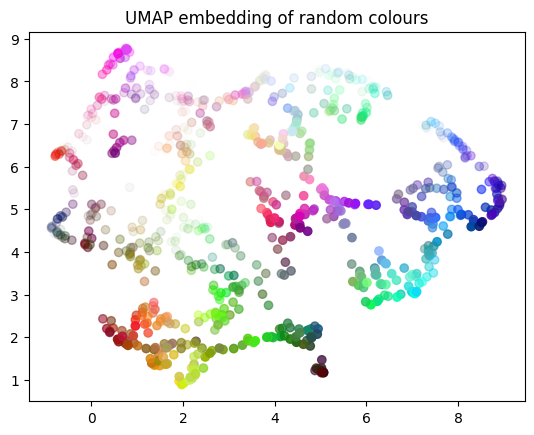

In [7]:
plt.scatter(x[:,0], x[:,1], c=data)
plt.title('UMAP embedding of random colours');

As we can see from the above graph, similar colors that are a representation from the 4D space are
embedded together. UMAP has several hyperparameters that can have a significant impact on the
resulting embedding and the notable ones are `n_neighbors`, `min_dist`, `n_components`, `metric`.

#### User Defined Function ####
we’ll now create a user defined function for plotting to make our exploration simpler.

In [8]:
def draw_umap(n_neighbors=15, min_dist=0.1, n_components=2, metric='euclidean', title=''):
    reducer = UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric
    )
    
    x = reducer.fit_transform(data);
    fig = plt.figure()
    
    if n_components == 1:
        ax = fig.add_subplot(111)
        ax.scatter(x[:,0], range(len(x)), c=data)
    
    if n_components == 2:
        ax = fig.add_subplot(111)
        ax.scatter(x[:,0], x[:,1], c=data)
    
    if n_components == 3:
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(x[:,0], x[:,1], x[:,2], c=data, s=100)
    
    plt.title(title)

**n_neighbors**  
This parameter controls how UMAP balances local versus global structure in the data. It does
this by constraining the size of the local neighborhood UMAP will look at when attempting to
learn the manifold structure of the data. This means that low values of n_neighbors will force
UMAP to concentrate on very local structure, while large values will push UMAP to look at larger
neighborhoods of each point when estimating the manifold structure of the data. But, this comes
at the cost of losing fine detail structure for the sake of getting the broader of the data.

There is a local/global tradeoff provided by the value of n_neighbors and one may choose the
neighborboods depending on the use case.

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


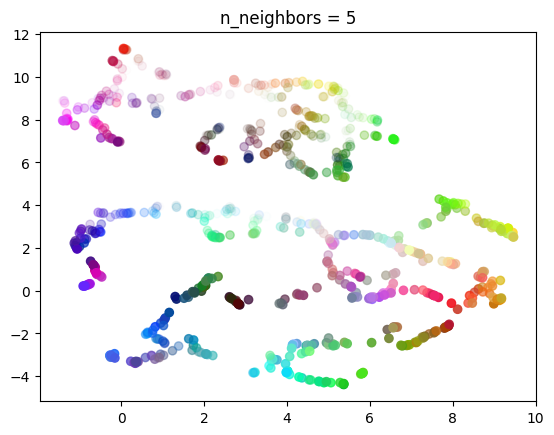

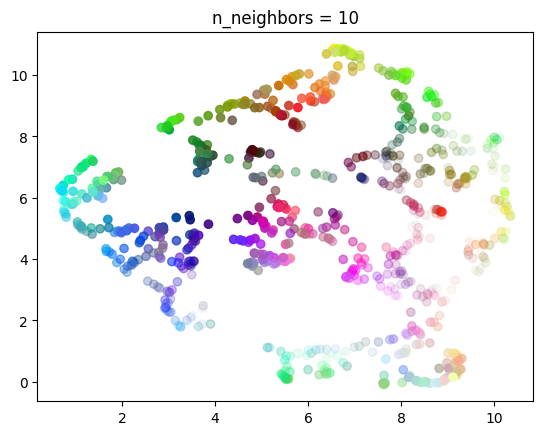

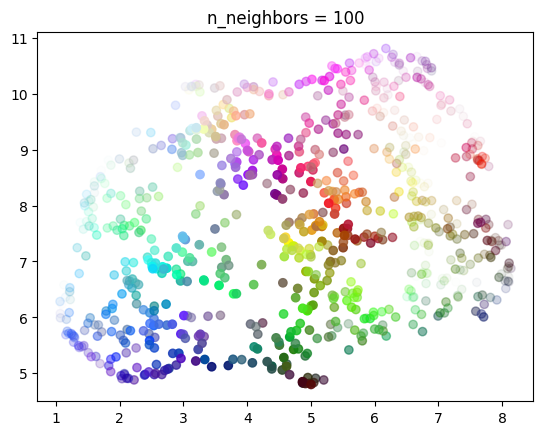

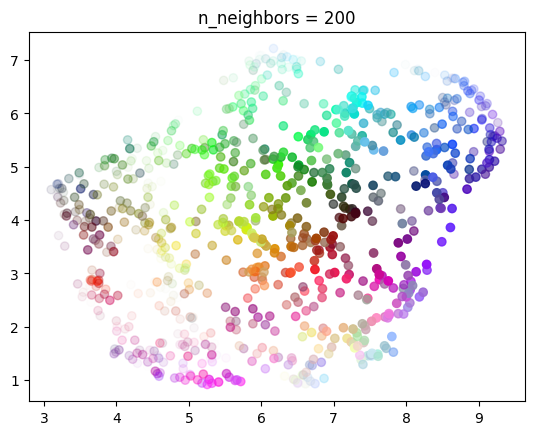

In [9]:
for n in (5, 10, 100, 200):
    draw_umap(n_neighbors=n, title=f'n_neighbors = {n}')

**min_dist**  
The min_dist parameter controls how tightly UMAP is allowed to pack points together. Low
values of min_dist will result in clumpier embeddings while larger values of min_dist will prevent
UMAP from packing points together and will focus on the preservation of the broad topological
structure.

We’ll now look range of values to visualize this behaviour.

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


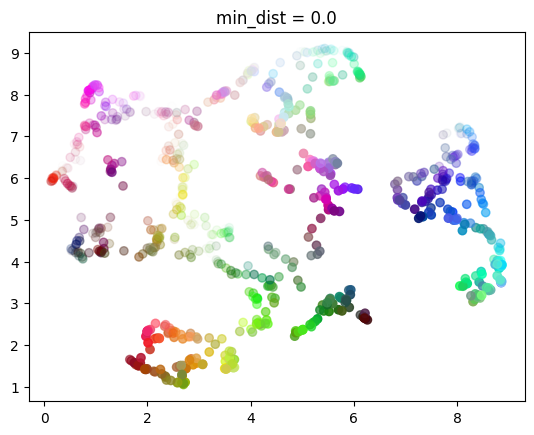

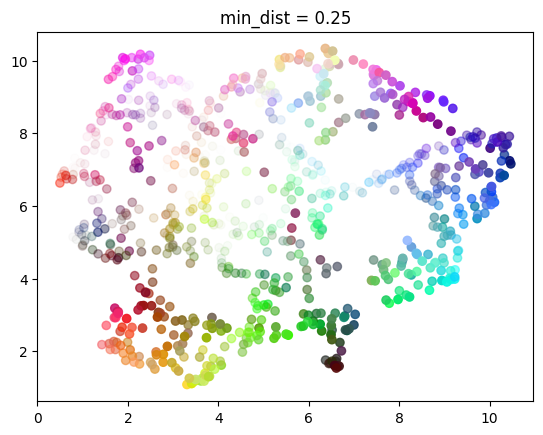

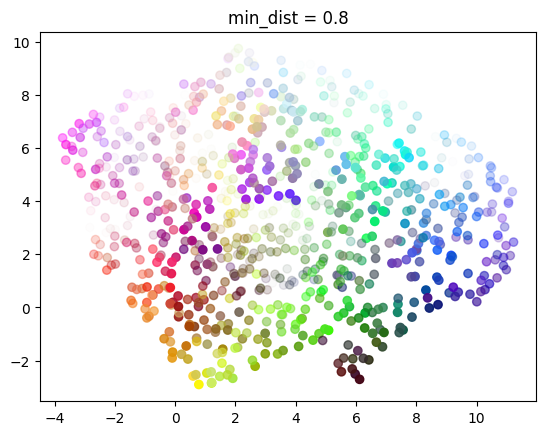

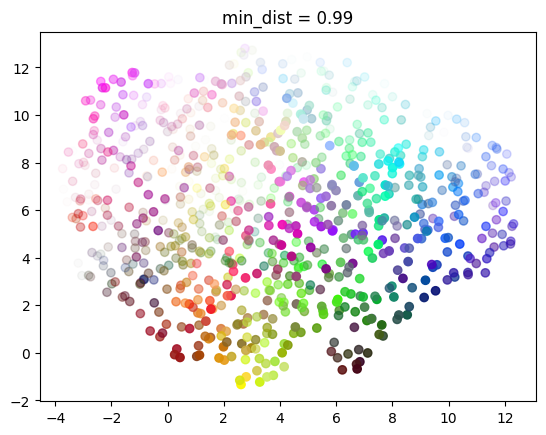

In [10]:
for d in (0.0, 0.25, 0.8, 0.99):
    draw_umap(min_dist=d, title=f'min_dist = {d}')

As seen from the plot above, as min_dist is increased the structures are pushed apart into softer
more general features, providing a better overarching view of the data. Of course, this comes at the
loss of the more detailed topological structure.

**n_components**  
The n_components parameter option allows us to determine the **dimensionality of the reduced
dimension space** that we will be embedding the data into. For the purposes of this exercise, we will
only be looking at 1D and 3D embeddings.

First, we’ll set n_components to 1, forcing UMAP to embed the data in a line. For visualisation
purposes we will randomly distribute the data on the y-axis to provide some separation between
points. We then try n_components = 3 and visualise it as basic 3D plot.

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


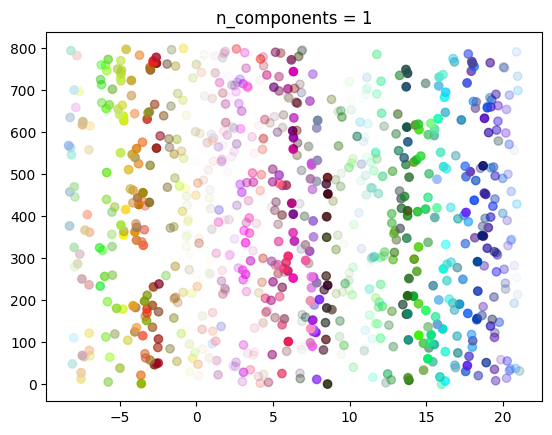

In [11]:
# 1D plot
draw_umap(n_components=1, title='n_components = 1')


/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


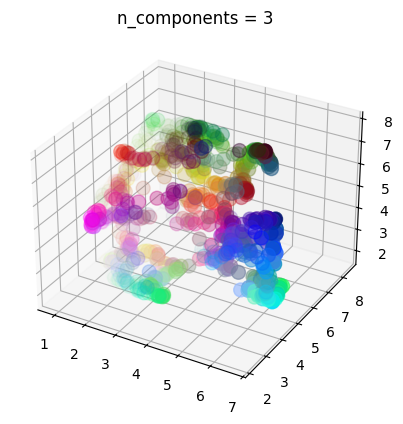

In [12]:
# 3D Plot
draw_umap(n_components=3, title='n_components = 3')

The ease of UMAP in which it separates out the colors colors by preserving the topological structure
of the data is the biggest strength. We can then easily scale up the dimensions to 50 or 100.


**metric**   
The metric parameter is used to compute distance in high dimensional space. UMAP supports a
wide variety of metrics as listed below:  
**Minkowski style metrics**
- euclidean
- manhattan
- chebyshev
- minkowski

**Miscellaneous spatial metrics**
- canberra
- braycurtis
- haversine

**Normalized spatial metrics**
- mahalanobis
- wminkowski
- seuclidean

**Angular and correlation metrics**
- cosine
- correlation

**Metrics for binary data**
- hamming
- jaccard
- dice
- russelrao
- kulsinski
- rogerstanimoto
- sokalmichener
- sokalsneath
- yule

UMAP also support custom user defined metrics as long as those metrics can be compiled in
nopython mode by numba. For detailed workings on this refer UMAP documentation.

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/umap/umap_.py:576: RuntimeWarning: overflow encountered in cast
  knn_dists = knn_dists.astype(np.float32

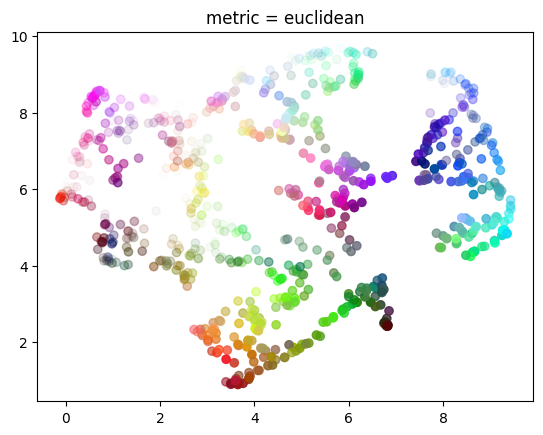

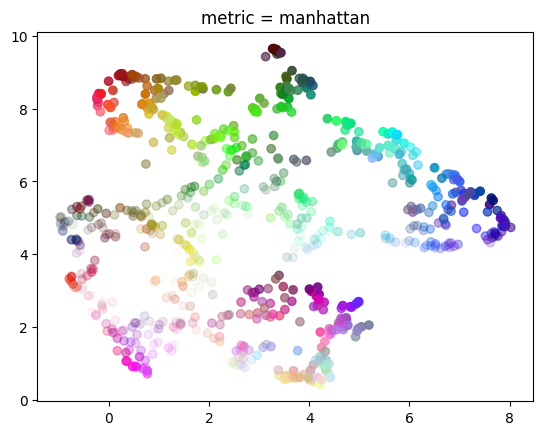

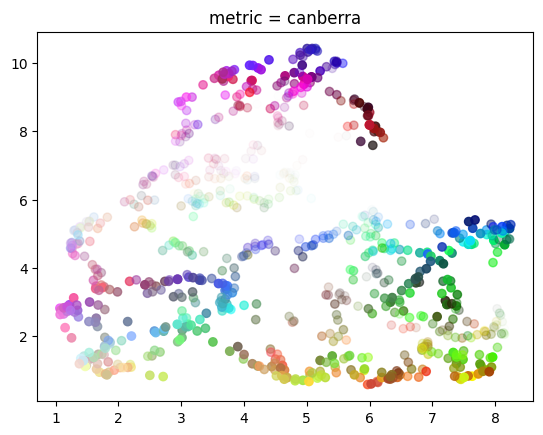

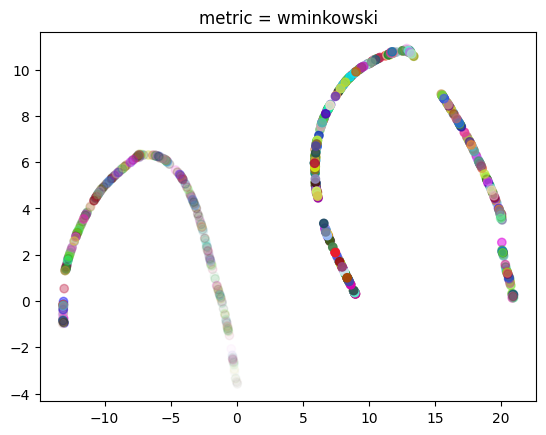

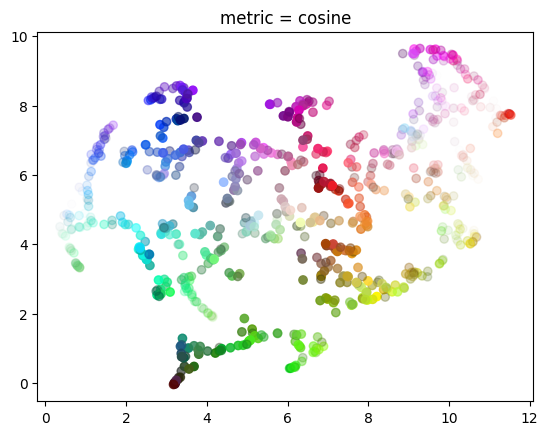

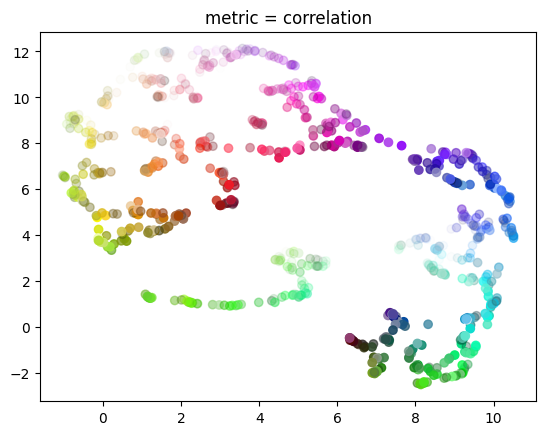

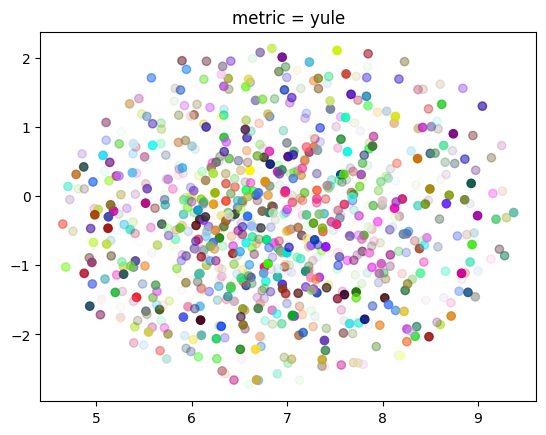

In [14]:
for x in ['euclidean', 'manhattan', 'canberra', 'wminkowski', 'cosine', 'correlation', 'yule']:
    draw_umap(metric = x, title=f'metric = {x}')

## Exercise 9 ##
Showcase the usage of UMAP as a feature extraction technique for classification problems. Use the
LinearSVC model to distinguish the performance pre and post-adaption of UMAP for feature extraction.
You’re expected to perform pipeline operations by integrating UMAP for hyperparameter
tuning.


Note: The above exercises are adapted from UMAP documentation. Use the Scikit-learn dataset
to generate classification data (toy dataset) and GridSearchCV for hyperparameter tuning.

#### UMAP as a Feature Extraction Technique for Classification ####
We use scikit-learn to create a dataset for a classification task. The dataset is then split into train
and test set. We then choose LinearSVC model to fit the classification problem with and without
the application of UMAP for feature extraction.

GridSearchCV is performed for hyperparameter tuning with 3 parameters n_neighbors,
n_components and SVC C. The performance of the model is then evaluated on the test set with
the accuracy metrics.

In [15]:
# Import libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [18]:
# Make a toy dataset
X, y = make_classification(
    n_samples=1000,
    n_features=100,
    n_informative=50,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    random_state=2022,
)

In [19]:
# Split the dataset into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
# Classification with a linear SVM
svc = LinearSVC(dual=False, random_state=123)

params_grid = {"C": [10 ** k for k in range(-3, 4)]}

clf = GridSearchCV(svc, params_grid)

clf.fit(X_train, y_train)

print(f"Accuracy on the test set with raw data: {clf.score(X_test, y_test):0.3}")

Accuracy on the test set with raw data: 0.825


The hyperparameter C in Support Vector Classification (SVC) controls the trade-off between margin width and classification accuracy. It determines how much importance is given to correctly classifying training examples versus allowing some errors for a broader decision boundary.

In [27]:
# Transformation with UMAP followed by classification with a linear SVM
umap = UMAP(random_state=456)
pipeline = Pipeline([("umap", umap), ("svc", svc)])

params_grid_pipeline = {
    "umap__n_neighbors": [5, 20],
    "umap__n_components": [15, 25, 50],
    "svc__C": [10 ** k for k in range(-3, 4)],
}

In [28]:
clf_pipeline = GridSearchCV(pipeline, params_grid_pipeline, n_jobs=-1)

In [29]:
clf_pipeline.fit(X_train, y_train)
print(f"Accuracy on the test set with UMAP transformation: {clf_pipeline.score(X_test, y_test):0.3}")

/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/py310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/ana

Accuracy on the test set with UMAP transformation: 0.955


# Before using UMAP, the test set accuracy was 0.825, after it's 0.955 #